# 3. Machine Learning for Classification

We'll use logistic regression to predict churn


## 3.1 Churn prediction project

* Dataset: https://www.kaggle.com/blastchar/telco-customer-churn
* https://raw.githubusercontent.com/sithvothykiv/ml-dataset/refs/heads/main/Telco-Customer-Churn.csv


## 3.2 Data preparation

* Download the data, read it with pandas
* Look at the data
* Make column names and values look uniform
* Check if all the columns read correctly
* Check if the churn variable needs any preparation

In [99]:
%pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [100]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [101]:
data = 'https://raw.githubusercontent.com/sithvothykiv/ml-dataset/refs/heads/main/Telco-Customer-Churn.csv'

In [102]:
!wget $data -O Telco-Customer-Churn.csv

--2026-02-28 13:28:02--  https://raw.githubusercontent.com/sithvothykiv/ml-dataset/refs/heads/main/Telco-Customer-Churn.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 970457 (948K) [text/plain]
Saving to: 'Telco-Customer-Churn.csv'

Telco-Customer-Chur 100%[===================>] 947.71K  4.13MB/s    in 0.2s    

2026-02-28 13:28:03 (4.13 MB/s) - 'Telco-Customer-Churn.csv' saved [970457/970457]



In [103]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [104]:
# 
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [105]:
df

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [106]:
# Transpose the DataFrame to view columns as rows
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
customerid,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU,9305-CDSKC,1452-KIOVK,6713-OKOMC,7892-POOKP,6388-TABGU
gender,Female,Male,Male,Male,Female,Female,Male,Female,Female,Male
seniorcitizen,0,0,0,0,0,0,0,0,0,0
partner,Yes,No,No,No,No,No,No,No,Yes,No
dependents,No,No,No,No,No,No,Yes,No,No,Yes
tenure,1,34,2,45,2,8,22,10,28,62
phoneservice,No,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Yes
multiplelines,No phone service,No,No,No phone service,No,Yes,Yes,No phone service,Yes,No
internetservice,DSL,DSL,DSL,DSL,Fiber optic,Fiber optic,Fiber optic,DSL,Fiber optic,DSL
onlinesecurity,No,Yes,Yes,Yes,No,No,No,Yes,No,Yes


In [107]:
df.totalcharges.isnull().sum()

np.int64(0)

In [108]:
pd.to_numeric(df.totalcharges)

ValueError: Unable to parse string " " at position 488

In [109]:
# Convert 'totalcharges' to numeric, coercing errors to NaN
tc = pd.to_numeric(df.totalcharges, errors='coerce')

In [110]:
tc.isnull().sum()

np.int64(11)

In [111]:
df[tc.isnull()]

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [112]:
df[tc.isnull()][['customerid','totalcharges']]

,customerid,totalcharges
488,4472-LVYGI,
753,3115-CZMZD,
936,5709-LVOEQ,
1082,4367-NUYAO,
1340,1371-DWPAZ,
3331,7644-OMVMY,
3826,3213-VVOLG,
4380,2520-SGTTA,
5218,2923-ARZLG,
6670,4075-WKNIU,


In [113]:
df.totalcharges

0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: totalcharges, Length: 7043, dtype: str

In [114]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')

In [115]:
df[df.totalcharges.isnull()][['customerid','totalcharges']]

,customerid,totalcharges
488,4472-LVYGI,NaN
753,3115-CZMZD,NaN
936,5709-LVOEQ,NaN
1082,4367-NUYAO,NaN
1340,1371-DWPAZ,NaN
3331,7644-OMVMY,NaN
3826,3213-VVOLG,NaN
4380,2520-SGTTA,NaN
5218,2923-ARZLG,NaN
6670,4075-WKNIU,NaN


In [116]:
df.totalcharges = df.totalcharges.fillna(0)

In [117]:
df[df.totalcharges.isnull()][['customerid','totalcharges']]

,customerid,totalcharges


In [118]:
df.churn.head(10)

0     No
1     No
2    Yes
3     No
4    Yes
5    Yes
6     No
7     No
8    Yes
9     No
Name: churn, dtype: str

In [119]:
df.churn

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: churn, Length: 7043, dtype: str

In [120]:
# Convert churn column to binary, where 'Yes' becomes 1 and 'No' becomes 0
(df.churn == 'Yes').astype(int).head(10)

0    0
1    0
2    1
3    0
4    1
5    1
6    0
7    0
8    1
9    0
Name: churn, dtype: int64

In [121]:
df.churn.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: churn, dtype: str

In [122]:
df.churn.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: churn, dtype: str

In [123]:
df.churn = (df.churn == 'Yes').astype(int)

In [124]:
df.churn.head()

0    0
1    0
2    1
3    0
4    1
Name: churn, dtype: int64

In [125]:
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
customerid,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU,9305-CDSKC,1452-KIOVK,6713-OKOMC,7892-POOKP,6388-TABGU
gender,Female,Male,Male,Male,Female,Female,Male,Female,Female,Male
seniorcitizen,0,0,0,0,0,0,0,0,0,0
partner,Yes,No,No,No,No,No,No,No,Yes,No
dependents,No,No,No,No,No,No,Yes,No,No,Yes
tenure,1,34,2,45,2,8,22,10,28,62
phoneservice,No,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Yes
multiplelines,No phone service,No,No,No phone service,No,Yes,Yes,No phone service,Yes,No
internetservice,DSL,DSL,DSL,DSL,Fiber optic,Fiber optic,Fiber optic,DSL,Fiber optic,DSL
onlinesecurity,No,Yes,Yes,Yes,No,No,No,Yes,No,Yes


## 3.3 Setting up the validation framework

* Perform the train/validation/test split with Scikit-Learn

In [126]:
# Import necessary libraries for model training and evaluation
from sklearn.model_selection import train_test_split

In [127]:
# Split the data into training, validation, and test sets
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)

In [128]:
df_full_train.churn.value_counts()

churn
0    4113
1    1521
Name: count, dtype: int64

In [129]:
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [130]:
# Check the sizes of the splits
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [131]:
df_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
3897,8015-IHCGW,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.50,8425.15,0
1980,1960-UYCNN,Male,0,No,No,10,Yes,Yes,Fiber optic,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,95.25,1021.55,0
6302,9250-WYPLL,Female,0,No,No,5,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,No,Electronic check,75.55,413.65,1
727,6786-OBWQR,Female,0,Yes,Yes,5,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,80.85,356.10,0
5104,1328-EUZHC,Female,0,Yes,No,18,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.10,370.50,0


In [132]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [133]:
df_train.head().T

,0,1,2,3,4
customerid,8015-IHCGW,1960-UYCNN,9250-WYPLL,6786-OBWQR,1328-EUZHC
gender,Female,Male,Female,Female,Female
seniorcitizen,0,0,0,0,0
partner,Yes,No,No,Yes,Yes
dependents,Yes,No,No,Yes,No
tenure,72,10,5,5,18
phoneservice,Yes,Yes,Yes,Yes,Yes
multiplelines,Yes,Yes,Yes,No,No
internetservice,Fiber optic,Fiber optic,Fiber optic,Fiber optic,No
onlinesecurity,Yes,No,No,No,No internet service


In [134]:
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

In [135]:
df_train

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,8015-IHCGW,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.50,8425.15,0
1,1960-UYCNN,Male,0,No,No,10,Yes,Yes,Fiber optic,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,95.25,1021.55,0
2,9250-WYPLL,Female,0,No,No,5,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,No,Electronic check,75.55,413.65,1
3,6786-OBWQR,Female,0,Yes,Yes,5,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,80.85,356.10,0
4,1328-EUZHC,Female,0,Yes,No,18,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.10,370.50,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4220,1309-XGFSN,Male,1,Yes,Yes,52,Yes,Yes,DSL,No,...,Yes,No,Yes,Yes,One year,Yes,Electronic check,80.85,4079.55,0
4221,4819-HJPIW,Male,0,No,No,18,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,No,Mailed check,25.15,476.80,0
4222,3703-VAVCL,Male,0,Yes,Yes,2,Yes,No,Fiber optic,No,...,Yes,Yes,No,Yes,Month-to-month,No,Credit card (automatic),90.00,190.05,1
4223,3812-LRZIR,Female,0,Yes,Yes,27,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Electronic check,24.50,761.95,0


In [136]:
del df_train['churn']
del df_val['churn']
del df_test['churn']

In [137]:
df_train.head().T

,0,1,2,3,4
customerid,8015-IHCGW,1960-UYCNN,9250-WYPLL,6786-OBWQR,1328-EUZHC
gender,Female,Male,Female,Female,Female
seniorcitizen,0,0,0,0,0
partner,Yes,No,No,Yes,Yes
dependents,Yes,No,No,Yes,No
tenure,72,10,5,5,18
phoneservice,Yes,Yes,Yes,Yes,Yes
multiplelines,Yes,Yes,Yes,No,No
internetservice,Fiber optic,Fiber optic,Fiber optic,Fiber optic,No
onlinesecurity,Yes,No,No,No,No internet service


## 3.4 EDA

* Check missing values
* Look at the target variable (churn)
* Look at numerical and categorical variables

In [138]:
len(df_full_train)

5634

In [139]:
df_full_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
1814,5442-PPTJY,Male,0,Yes,Yes,12,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.70,258.35,0
5946,6261-RCVNS,Female,0,No,No,42,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,One year,No,Credit card (automatic),73.90,3160.55,1
3881,2176-OSJUV,Male,0,Yes,No,71,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),65.15,4681.75,0
2389,6161-ERDGD,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,85.45,6300.85,0
3676,2364-UFROM,Male,0,No,No,30,Yes,No,DSL,Yes,...,No,Yes,Yes,No,One year,No,Electronic check,70.40,2044.75,0


In [140]:
df_full_train = df_full_train.reset_index(drop=True)

In [141]:
df_full_train

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-PPTJY,Male,0,Yes,Yes,12,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.70,258.35,0
1,6261-RCVNS,Female,0,No,No,42,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,One year,No,Credit card (automatic),73.90,3160.55,1
2,2176-OSJUV,Male,0,Yes,No,71,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),65.15,4681.75,0
3,6161-ERDGD,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,85.45,6300.85,0
4,2364-UFROM,Male,0,No,No,30,Yes,No,DSL,Yes,...,No,Yes,Yes,No,One year,No,Electronic check,70.40,2044.75,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0781-LKXBR,Male,1,No,No,9,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.50,918.60,1
5630,3507-GASNP,Male,0,No,Yes,60,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.95,1189.90,0
5631,8868-WOZGU,Male,0,No,No,28,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.70,2979.50,1
5632,1251-KRREG,Male,0,No,No,2,Yes,Yes,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,54.40,114.10,1


In [142]:
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [143]:
df_full_train.churn.value_counts(normalize=True)

churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64

In [144]:
# df_full_train.churn = (df.churn == 'Yes').astype(int)

In [145]:
df_full_train.churn.mean()

np.float64(0.26996805111821087)

In [146]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']
numerical

['tenure', 'monthlycharges', 'totalcharges']

In [147]:
categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]
categorical

['gender',
 'seniorcitizen',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod']

In [148]:
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

In [149]:
df_full_train[categorical].head(10).T

,0,1,2,3,4,5,6,7,8,9
gender,Male,Female,Male,Male,Male,Female,Male,Male,Male,Female
seniorcitizen,0,0,0,0,0,0,0,0,1,1
partner,Yes,No,Yes,Yes,No,Yes,Yes,No,Yes,Yes
dependents,Yes,No,No,Yes,No,Yes,No,No,No,Yes
phoneservice,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
multiplelines,No,No,Yes,Yes,No,No,Yes,No,Yes,No
internetservice,No,DSL,DSL,DSL,DSL,DSL,Fiber optic,Fiber optic,Fiber optic,Fiber optic
onlinesecurity,No internet service,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No
onlinebackup,No internet service,Yes,Yes,No,Yes,Yes,Yes,No,No,No
deviceprotection,No internet service,Yes,No,Yes,No,Yes,Yes,Yes,Yes,No


## 3.5 Feature importance: Churn rate and risk ratio

Feature importance analysis (part of EDA) - identifying which features affect our target variable

* Churn rate
* Risk ratio
* Mutual information - later

#### Churn rate

In [150]:
df_full_train

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-PPTJY,Male,0,Yes,Yes,12,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.70,258.35,0
1,6261-RCVNS,Female,0,No,No,42,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,One year,No,Credit card (automatic),73.90,3160.55,1
2,2176-OSJUV,Male,0,Yes,No,71,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),65.15,4681.75,0
3,6161-ERDGD,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,85.45,6300.85,0
4,2364-UFROM,Male,0,No,No,30,Yes,No,DSL,Yes,...,No,Yes,Yes,No,One year,No,Electronic check,70.40,2044.75,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0781-LKXBR,Male,1,No,No,9,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.50,918.60,1
5630,3507-GASNP,Male,0,No,Yes,60,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.95,1189.90,0
5631,8868-WOZGU,Male,0,No,No,28,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.70,2979.50,1
5632,1251-KRREG,Male,0,No,No,2,Yes,Yes,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,54.40,114.10,1


In [151]:
global_churn = df_full_train.churn.mean()
global_churn

np.float64(0.26996805111821087)

In [152]:
churn_female = df_full_train[df_full_train.gender == 'Female'].churn.mean()
churn_female

np.float64(0.27682403433476394)

In [153]:
global_churn - churn_female

np.float64(-0.006855983216553063)

In [154]:
churn_male = df_full_train[df_full_train.gender == 'Male'].churn.mean()
churn_male

np.float64(0.2632135306553911)

In [155]:
global_churn - churn_male

np.float64(0.006754520462819769)

In [156]:
df_full_train.partner.value_counts()

partner
No     2932
Yes    2702
Name: count, dtype: int64

In [157]:
df_full_train.partner

0       Yes
1        No
2       Yes
3       Yes
4        No
       ... 
5629     No
5630     No
5631     No
5632     No
5633    Yes
Name: partner, Length: 5634, dtype: str

In [158]:
churn_partner = df_full_train[df_full_train.partner == 'Yes'].churn.mean()
churn_partner

np.float64(0.20503330866025166)

In [159]:
global_churn - churn_partner

np.float64(0.06493474245795922)

In [160]:
churn_no_partner = df_full_train[df_full_train.partner == 'No'].churn.mean()
churn_no_partner

np.float64(0.3298090040927694)

In [161]:
global_churn - churn_no_partner

np.float64(-0.05984095297455855)

#### Risk ratio

In [162]:
global_churn, churn_no_partner

(np.float64(0.26996805111821087), np.float64(0.3298090040927694))

In [163]:
churn_no_partner / global_churn

np.float64(1.2216593879412643)

In [164]:
churn_partner / global_churn

np.float64(0.7594724924338315)

In [165]:
from IPython.display import display

In [166]:
categorical

['gender',
 'seniorcitizen',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod']

In [167]:
for c in categorical:
    print(c)
    df_group = df_full_train.groupby(c).churn.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_churn
    df_group['risk'] = df_group['mean'] / global_churn
    display(df_group)
    print()

gender


,mean,count,diff,risk
gender,,,,
Female,0.276824,2796,0.006856,1.025396
Male,0.263214,2838,-0.006755,0.974980



seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208



partner


...

,mean,count,diff,risk
contract,,,,
Month-to-month,0.431701,3104,0.161733,1.599082
One year,0.120573,1186,-0.149395,0.446621
Two year,0.028274,1344,-0.241694,0.104730



paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
No,0.172071,2313,-0.097897,0.637375
Yes,0.338151,3321,0.068183,1.252560



paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
Bank transfer (automatic),0.168171,1219,-0.101797,0.622928
Credit card (automatic),0.164339,1217,-0.105630,0.608733
Electronic check,0.455890,1893,0.185922,1.688682
Mailed check,0.193870,1305,-0.076098,0.718121


## 3.6 Feature importance: Mutual information

Mutual information - concept from information theory, it tells us how much
we can learn about one variable if we know the value of another

* https://en.wikipedia.org/wiki/Mutual_information

In [168]:
df_full_train

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-PPTJY,Male,0,Yes,Yes,12,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.70,258.35,0
1,6261-RCVNS,Female,0,No,No,42,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,One year,No,Credit card (automatic),73.90,3160.55,1
2,2176-OSJUV,Male,0,Yes,No,71,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),65.15,4681.75,0
3,6161-ERDGD,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,85.45,6300.85,0
4,2364-UFROM,Male,0,No,No,30,Yes,No,DSL,Yes,...,No,Yes,Yes,No,One year,No,Electronic check,70.40,2044.75,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0781-LKXBR,Male,1,No,No,9,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.50,918.60,1
5630,3507-GASNP,Male,0,No,Yes,60,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.95,1189.90,0
5631,8868-WOZGU,Male,0,No,No,28,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.70,2979.50,1
5632,1251-KRREG,Male,0,No,No,2,Yes,Yes,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,54.40,114.10,1


In [169]:
from sklearn.metrics import mutual_info_score

In [170]:
df_full_train.contract

0             Two year
1             One year
2             Two year
3             One year
4             One year
             ...      
5629    Month-to-month
5630          Two year
5631    Month-to-month
5632    Month-to-month
5633          Two year
Name: contract, Length: 5634, dtype: str

In [171]:
df_full_train.churn

0       0
1       1
2       0
3       0
4       0
       ..
5629    1
5630    0
5631    1
5632    1
5633    0
Name: churn, Length: 5634, dtype: int64

In [172]:
df_full_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-PPTJY,Male,0,Yes,Yes,12,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.70,258.35,0
1,6261-RCVNS,Female,0,No,No,42,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,One year,No,Credit card (automatic),73.90,3160.55,1
2,2176-OSJUV,Male,0,Yes,No,71,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),65.15,4681.75,0
3,6161-ERDGD,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,85.45,6300.85,0
4,2364-UFROM,Male,0,No,No,30,Yes,No,DSL,Yes,...,No,Yes,Yes,No,One year,No,Electronic check,70.40,2044.75,0


In [173]:
mutual_info_score(df.churn, df.contract)

0.09845305342598942

In [174]:
mutual_info_score(df.gender, df.churn)

3.7082914405128786e-05

In [175]:
mutual_info_score(df.contract, df.churn)

0.09845305342598942

In [176]:
mutual_info_score(df.partner, df.churn)

0.011453657253317984

In [177]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df.churn)

In [178]:
categorical

['gender',
 'seniorcitizen',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod']

In [179]:
df.churn

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: churn, Length: 7043, dtype: int64

In [180]:
mi = df[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

contract            0.098453
onlinesecurity      0.064677
techsupport         0.063021
internetservice     0.055574
onlinebackup        0.046792
paymentmethod       0.044519
deviceprotection    0.043917
streamingmovies     0.032001
streamingtv         0.031908
paperlessbilling    0.019194
dependents          0.014467
partner             0.011454
seniorcitizen       0.010577
multiplelines       0.000801
phoneservice        0.000072
gender              0.000037
dtype: float64

## 3.7 Feature importance: Correlation

How about numerical columns?

* Correlation coefficient - https://en.wikipedia.org/wiki/Pearson_correlation_coefficient

In [181]:
df_full_train.tenure.max()

np.int64(72)

In [182]:
df_full_train

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-PPTJY,Male,0,Yes,Yes,12,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.70,258.35,0
1,6261-RCVNS,Female,0,No,No,42,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,One year,No,Credit card (automatic),73.90,3160.55,1
2,2176-OSJUV,Male,0,Yes,No,71,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),65.15,4681.75,0
3,6161-ERDGD,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,85.45,6300.85,0
4,2364-UFROM,Male,0,No,No,30,Yes,No,DSL,Yes,...,No,Yes,Yes,No,One year,No,Electronic check,70.40,2044.75,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0781-LKXBR,Male,1,No,No,9,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.50,918.60,1
5630,3507-GASNP,Male,0,No,Yes,60,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.95,1189.90,0
5631,8868-WOZGU,Male,0,No,No,28,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.70,2979.50,1
5632,1251-KRREG,Male,0,No,No,2,Yes,Yes,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,54.40,114.10,1


In [207]:
numerical

['tenure', 'monthlycharges', 'totalcharges']

In [208]:
df_full_train.churn

0       0
1       1
2       0
3       0
4       0
       ..
5629    1
5630    0
5631    1
5632    1
5633    0
Name: churn, Length: 5634, dtype: int64

In [184]:
# df_full_train[numerical].corrwith(df.churn).abs()
df_full_train[numerical].corrwith(df_full_train.churn).abs()

tenure            0.351885
monthlycharges    0.196805
totalcharges      0.196353
dtype: float64

<Axes: >

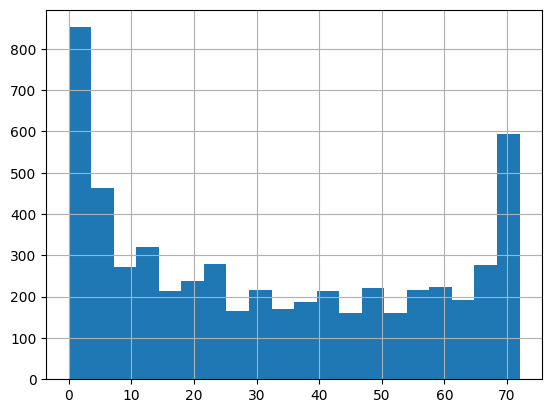

In [210]:
df_full_train.tenure.hist(bins=20)

In [211]:
df_full_train[df_full_train.tenure <= 2].churn.mean()

np.float64(0.5953420669577875)

In [212]:
df_full_train[(df_full_train.tenure > 2) & (df_full_train.tenure <= 12)].churn.mean()

np.float64(0.3994413407821229)

In [213]:
df_full_train[df_full_train.tenure > 12].churn.mean()

np.float64(0.17634908339788277)

In [188]:
df_full_train[df_full_train.monthlycharges <= 20].churn.mean()

np.float64(0.08795411089866156)

In [189]:
df_full_train[(df_full_train.monthlycharges > 20) & (df_full_train.monthlycharges <= 50)].churn.mean()

np.float64(0.18340943683409436)

In [214]:
df_full_train[df_full_train.monthlycharges > 50].churn.mean()

np.float64(0.32499341585462205)

## 3.8 One-hot encoding

* Use Scikit-Learn to encode categorical features

In [191]:
from sklearn.feature_extraction import DictVectorizer

In [215]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

In [221]:
train_dict

[{'gender': 'Female',
  'seniorcitizen': 0,
  'partner': 'Yes',
  'dependents': 'Yes',
  'phoneservice': 'Yes',
  'multiplelines': 'Yes',
  'internetservice': 'Fiber optic',
  'onlinesecurity': 'Yes',
  'onlinebackup': 'Yes',
  'deviceprotection': 'Yes',
  'techsupport': 'Yes',
  'streamingtv': 'Yes',
  'streamingmovies': 'Yes',
  'contract': 'Two year',
  'paperlessbilling': 'Yes',
  'paymentmethod': 'Electronic check',
  'tenure': 72,
  'monthlycharges': 115.5,
  'totalcharges': 8425.15},
 {'gender': 'Male',
  'seniorcitizen': 0,
  'partner': 'No',
  'dependents': 'No',
  'phoneservice': 'Yes',
  'multiplelines': 'Yes',
  'internetservice': 'Fiber optic',
  'onlinesecurity': 'No',
  'onlinebackup': 'Yes',
  'deviceprotection': 'Yes',
  'techsupport': 'No',
  'streamingtv': 'No',
  'streamingmovies': 'Yes',
  'contract': 'Month-to-month',
  'paperlessbilling': 'Yes',
  'paymentmethod': 'Electronic check',
  'tenure': 10,
  'monthlycharges': 95.25,
  'totalcharges': 1021.55},
 {'gender

In [217]:
X_train, X_val

(array([[0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
         7.20000e+01, 8.42515e+03],
        [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
         1.00000e+01, 1.02155e+03],
        [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
         5.00000e+00, 4.13650e+02],
        ...,
        [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
         2.00000e+00, 1.90050e+02],
        [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
         2.70000e+01, 7.61950e+02],
        [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
         9.00000e+00, 7.51650e+02]], shape=(4225, 45)),
 array([[0.0000e+00, 0.0000e+00, 1.0000e+00, ..., 1.0000e+00, 7.1000e+01,
         4.9734e+03],
        [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.0000e+00,
         2.0750e+01],
        [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.0000e+00,
         2.0350e+01],
        ...,
        [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 1.00

## 3.9 Logistic regression

* Binary classification
* Linear vs logistic regression

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [196]:
z = np.linspace(-7, 7, 51)
z

array([-7.0000000e+00, -6.7200000e+00, -6.4400000e+00, -6.1600000e+00,
       -5.8800000e+00, -5.6000000e+00, -5.3200000e+00, -5.0400000e+00,
       -4.7600000e+00, -4.4800000e+00, -4.2000000e+00, -3.9200000e+00,
       -3.6400000e+00, -3.3600000e+00, -3.0800000e+00, -2.8000000e+00,
       -2.5200000e+00, -2.2400000e+00, -1.9600000e+00, -1.6800000e+00,
       -1.4000000e+00, -1.1200000e+00, -8.4000000e-01, -5.6000000e-01,
       -2.8000000e-01,  8.8817842e-16,  2.8000000e-01,  5.6000000e-01,
        8.4000000e-01,  1.1200000e+00,  1.4000000e+00,  1.6800000e+00,
        1.9600000e+00,  2.2400000e+00,  2.5200000e+00,  2.8000000e+00,
        3.0800000e+00,  3.3600000e+00,  3.6400000e+00,  3.9200000e+00,
        4.2000000e+00,  4.4800000e+00,  4.7600000e+00,  5.0400000e+00,
        5.3200000e+00,  5.6000000e+00,  5.8800000e+00,  6.1600000e+00,
        6.4400000e+00,  6.7200000e+00,  7.0000000e+00])

In [197]:
sigmoid(10000)

np.float64(1.0)

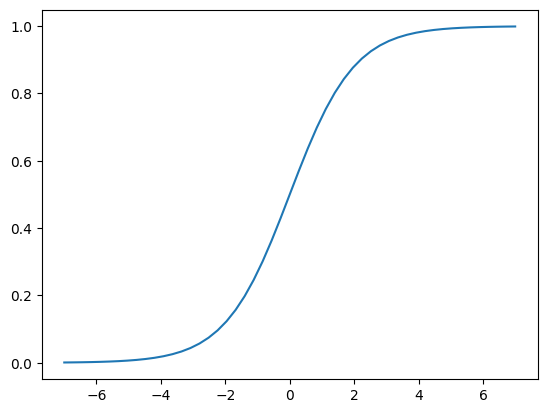

In [198]:
plt.plot(z, sigmoid(z))

In [199]:
def linear_regression(xi):
    result = w0

    for j in range(len(w)):
        result = result + xi[j] * w[j]

    return result

In [200]:
def logistic_regression(xi):
    score = w0

    for j in range(len(w)):
        score = score + xi[j] * w[j]

    result = sigmoid(score)
    return result

## 3.10 Training logistic regression with Scikit-Learn

* Train a model with Scikit-Learn
* Apply it to the validation dataset
* Calculate the accuracy

In [201]:
from sklearn.linear_model import LogisticRegression

In [202]:
model = LogisticRegression(solver='lbfgs')
# solver='lbfgs' is the default solver in newer version of sklearn
# for older versions, you need to specify it explicitly
model.fit(X_train, y_train)

/Users/kivsithvothy/Downloads/ml-weekend-sunrise/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [223]:
model.coef_[0]

array([ 4.74734335e-01, -1.74858490e-01, -4.07548642e-01, -2.97020087e-02,
       -7.79707879e-02,  6.26755151e-02, -8.89697808e-02, -8.13785308e-02,
       -3.43071929e-02, -7.33656037e-02, -3.35188192e-01,  3.16485176e-01,
       -8.89697808e-02,  3.67714743e-03, -2.58117170e-01,  1.41447972e-01,
        8.99640201e-03,  6.25238969e-02, -8.89697808e-02, -8.12269126e-02,
        2.65560306e-01, -8.89697808e-02, -2.84263322e-01, -2.31171659e-01,
        1.23498863e-01, -1.66026164e-01,  5.83533670e-02, -8.70026406e-02,
       -3.20502434e-02,  7.04550003e-02, -5.90749129e-02,  1.41447972e-01,
       -2.49120768e-01,  2.15459840e-01, -1.20360928e-01, -8.89697808e-02,
        1.01657913e-01, -7.08911614e-02, -8.89697808e-02,  5.21881456e-02,
        2.13349721e-01, -8.89697808e-02, -2.32052737e-01, -7.04053864e-02,
        3.82354818e-04])

In [205]:
model.coef_[0].round(3)

array([ 0.475, -0.175, -0.408, -0.03 , -0.078,  0.063, -0.089, -0.081,
       -0.034, -0.073, -0.335,  0.316, -0.089,  0.004, -0.258,  0.141,
        0.009,  0.063, -0.089, -0.081,  0.266, -0.089, -0.284, -0.231,
        0.123, -0.166,  0.058, -0.087, -0.032,  0.07 , -0.059,  0.141,
       -0.249,  0.215, -0.12 , -0.089,  0.102, -0.071, -0.089,  0.052,
        0.213, -0.089, -0.232, -0.07 ,  0.   ])

In [206]:
model.intercept_[0]

np.float64(-0.10902792548978092)

In [ ]:
model.coef_[0].round(3)

array([ 0.564, -0.154, -0.519, -0.013, -0.095,  0.071, -0.098, -0.082,
       -0.033, -0.076, -0.354,  0.343, -0.098,  0.002, -0.251,  0.162,
       -0.02 ,  0.066, -0.098, -0.076,  0.251, -0.098, -0.261, -0.228,
        0.119, -0.121,  0.012, -0.095, -0.03 ,  0.045, -0.028,  0.162,
       -0.271,  0.221, -0.097, -0.098,  0.087, -0.05 , -0.098,  0.039,
        0.194, -0.098, -0.205, -0.072,  0.   ])

In [225]:
X_val[:, 1]

array([0., 0., 0., ..., 0., 0., 0.], shape=(1409,))

In [228]:
y_pred = model.predict_proba(X_val)[:, 1]
y_pred.round(2)

array([0.01, 0.2 , 0.21, ..., 0.14, 0.8 , 0.84], shape=(1409,))

In [230]:
churn_decision = (y_pred >= 0.5)
churn_decision

array([False, False, False, ..., False,  True,  True], shape=(1409,))

In [231]:
y_val

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

In [232]:
(y_val == churn_decision).mean()

np.float64(0.8034066713981547)

In [ ]:
y_val

array([0, 0, 0, ..., 0, 1, 1])

In [ ]:
df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
df_pred['prediction'] = churn_decision.astype(int)
df_pred['actual'] = y_val

In [ ]:
df_pred

,probability,prediction,actual,correct
0,0.007863,0,0,True
1,0.209928,0,0,True
2,0.223710,0,0,True
3,0.561123,1,1,True
4,0.219586,0,0,True
...,...,...,...,...
1404,0.297790,0,0,True
1405,0.035463,0,1,False
1406,0.150149,0,0,True
1407,0.776681,1,1,True


In [ ]:
df_pred.actual

,actual
0,0
1,0
2,0
3,1
4,0
...,...
1404,0
1405,1
1406,0
1407,1


In [ ]:
df_pred['correct'] = df_pred.prediction == df_pred.actual

In [ ]:
df_val[churn_decision]

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
12,7228-omtpn,male,0,no,no,4,yes,no,fiber_optic,no,no,no,no,yes,yes,month-to-month,yes,electronic_check,88.45,370.65
30,3074-gqwyx,male,0,no,no,5,yes,yes,fiber_optic,no,no,no,no,no,no,month-to-month,yes,bank_transfer_(automatic),75.90,357.75
35,3859-cvcet,female,0,no,no,4,yes,no,dsl,no,no,no,no,no,no,month-to-month,no,mailed_check,45.65,191.05
37,9396-zsfll,female,0,no,no,15,yes,yes,dsl,no,no,no,no,no,no,month-to-month,no,mailed_check,48.85,631.40
42,2230-xtuwl,female,0,yes,yes,48,yes,no,no,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.55,883.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1392,0319-qztco,female,0,yes,yes,3,yes,no,dsl,no,yes,no,no,yes,no,month-to-month,yes,credit_card_(automatic),58.70,168.60
1395,5366-obvmr,female,0,yes,no,18,yes,no,dsl,no,no,no,yes,no,no,month-to-month,yes,mailed_check,50.30,908.75
1403,8879-xuahx,male,0,yes,no,71,yes,yes,fiber_optic,yes,yes,yes,yes,yes,yes,two_year,yes,electronic_check,116.25,8564.75
1404,0980-pvmrc,female,0,yes,yes,40,no,no_phone_service,dsl,no,yes,no,no,yes,yes,month-to-month,yes,electronic_check,50.85,2036.55


In [ ]:
df_pred.correct.mean()

np.float64(0.801277501774308)

In [ ]:
churn_decision.astype(int)

array([0, 0, 0, ..., 0, 1, 1])

## 3.11 Model interpretation

* Look at the coefficients
* Train a smaller model with fewer features

In [ ]:
a = [1, 2, 3, 4]
b = 'abcd'

In [ ]:
list(zip(a, b))

[(1, 'a'), (2, 'b'), (3, 'c'), (4, 'd')]

In [ ]:
dict(zip(a, b))

{1: 'a', 2: 'b', 3: 'c', 4: 'd'}

In [ ]:
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen',
       'streamingmovies=no', 'streamingmovies=no_internet_service',

In [ ]:
dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))

{'contract=month-to-month': np.float64(0.481),
 'contract=one_year': np.float64(-0.172),
 'contract=two_year': np.float64(-0.443),
 'dependents=no': np.float64(-0.052),
 'dependents=yes': np.float64(-0.083),
 'deviceprotection=no': np.float64(0.044),
 'deviceprotection=no_internet_service': np.float64(-0.103),
 'deviceprotection=yes': np.float64(-0.076),
 'gender=female': np.float64(-0.049),
 'gender=male': np.float64(-0.086),
 'internetservice=dsl': np.float64(-0.347),
 'internetservice=fiber_optic': np.float64(0.315),
 'internetservice=no': np.float64(-0.103),
 'monthlycharges': np.float64(0.004),
 'multiplelines=no': np.float64(-0.214),
 'multiplelines=no_phone_service': np.float64(0.098),
 'multiplelines=yes': np.float64(-0.019),
 'onlinebackup=no': np.float64(0.095),
 'onlinebackup=no_internet_service': np.float64(-0.103),
 'onlinebackup=yes': np.float64(-0.127),
 'onlinesecurity=no': np.float64(0.206),
 'onlinesecurity=no_internet_service': np.float64(-0.103),
 'onlinesecurity=ye

In [233]:
small = ['contract', 'tenure', 'monthlycharges']
small

['contract', 'tenure', 'monthlycharges']

In [ ]:
df_train[small].iloc[:10]

,contract,tenure,monthlycharges
0,two_year,72,115.50
1,month-to-month,10,95.25
2,month-to-month,5,75.55
3,month-to-month,5,80.85
4,two_year,18,20.10
5,month-to-month,4,30.50
6,month-to-month,1,75.10
7,month-to-month,1,70.30
8,two_year,72,19.75
9,month-to-month,6,109.90


In [ ]:
df_val[small].iloc[:10]

,contract,tenure,monthlycharges
0,two_year,71,70.85
1,month-to-month,1,20.75
2,month-to-month,1,20.35
3,month-to-month,2,75.70
4,month-to-month,1,19.90
5,month-to-month,16,49.45
6,one_year,39,41.15
7,two_year,68,25.75
8,month-to-month,6,99.95
9,month-to-month,1,45.70


In [234]:
df_train[small].iloc[:10].to_dict(orient='records')

[{'contract': 'Two year', 'tenure': 72, 'monthlycharges': 115.5},
 {'contract': 'Month-to-month', 'tenure': 10, 'monthlycharges': 95.25},
 {'contract': 'Month-to-month', 'tenure': 5, 'monthlycharges': 75.55},
 {'contract': 'Month-to-month', 'tenure': 5, 'monthlycharges': 80.85},
 {'contract': 'Two year', 'tenure': 18, 'monthlycharges': 20.1},
 {'contract': 'Month-to-month', 'tenure': 4, 'monthlycharges': 30.5},
 {'contract': 'Month-to-month', 'tenure': 1, 'monthlycharges': 75.1},
 {'contract': 'Month-to-month', 'tenure': 1, 'monthlycharges': 70.3},
 {'contract': 'Two year', 'tenure': 72, 'monthlycharges': 19.75},
 {'contract': 'Month-to-month', 'tenure': 6, 'monthlycharges': 109.9}]

In [235]:
dicts_train_small = df_train[small].to_dict(orient='records')
dicts_val_small = df_val[small].to_dict(orient='records')

In [236]:
dv_small = DictVectorizer(sparse=False)
dv_small.fit(dicts_train_small)

,"dtype dtype: dtype, default=np.float64The type of feature values. Passed to Numpy array/scipy.sparse matrixconstructors as the dtype argument.",<class 'numpy.float64'>
,"separator separator: str, default=""=""Separator string used when constructing new features for one-hotcoding.",'='
,"sparse sparse: bool, default=TrueWhether transform should produce scipy.sparse matrices.",False
,"sort sort: bool, default=TrueWhether ``feature_names_`` and ``vocabulary_`` should besorted when fitting.",True


In [237]:
dv_small.get_feature_names_out()

array(['contract=Month-to-month', 'contract=One year',
       'contract=Two year', 'monthlycharges', 'tenure'], dtype=object)

In [238]:
dicts_train_small

[{'contract': 'Two year', 'tenure': 72, 'monthlycharges': 115.5},
 {'contract': 'Month-to-month', 'tenure': 10, 'monthlycharges': 95.25},
 {'contract': 'Month-to-month', 'tenure': 5, 'monthlycharges': 75.55},
 {'contract': 'Month-to-month', 'tenure': 5, 'monthlycharges': 80.85},
 {'contract': 'Two year', 'tenure': 18, 'monthlycharges': 20.1},
 {'contract': 'Month-to-month', 'tenure': 4, 'monthlycharges': 30.5},
 {'contract': 'Month-to-month', 'tenure': 1, 'monthlycharges': 75.1},
 {'contract': 'Month-to-month', 'tenure': 1, 'monthlycharges': 70.3},
 {'contract': 'Two year', 'tenure': 72, 'monthlycharges': 19.75},
 {'contract': 'Month-to-month', 'tenure': 6, 'monthlycharges': 109.9},
 {'contract': 'Two year', 'tenure': 72, 'monthlycharges': 99.9},
 {'contract': 'Month-to-month', 'tenure': 17, 'monthlycharges': 102.55},
 {'contract': 'Two year', 'tenure': 66, 'monthlycharges': 58.2},
 {'contract': 'Month-to-month', 'tenure': 2, 'monthlycharges': 68.95},
 {'contract': 'Month-to-month', 't

In [239]:
X_train_small = dv_small.transform(dicts_train_small)
X_train_small

array([[  0.  ,   0.  ,   1.  , 115.5 ,  72.  ],
       [  1.  ,   0.  ,   0.  ,  95.25,  10.  ],
       [  1.  ,   0.  ,   0.  ,  75.55,   5.  ],
       ...,
       [  1.  ,   0.  ,   0.  ,  90.  ,   2.  ],
       [  0.  ,   0.  ,   1.  ,  24.5 ,  27.  ],
       [  1.  ,   0.  ,   0.  ,  80.85,   9.  ]], shape=(4225, 5))

In [240]:
model_small = LogisticRegression(solver='lbfgs')
model_small.fit(X_train_small, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [241]:
w0 = model_small.intercept_[0]
w0

np.float64(-2.477957597647984)

In [242]:
w = model_small.coef_[0]
w.round(3)

array([ 0.971, -0.024, -0.948,  0.027, -0.036])

In [243]:
dict(zip(dv_small.get_feature_names_out(), w.round(3)))

{'contract=Month-to-month': np.float64(0.971),
 'contract=One year': np.float64(-0.024),
 'contract=Two year': np.float64(-0.948),
 'monthlycharges': np.float64(0.027),
 'tenure': np.float64(-0.036)}

In [244]:
-2.47 + (-0.949) + 30 * 0.027 + 24 * (-0.036)

-3.473

In [245]:
sigmoid(_)

np.float64(0.030090303318277657)

In [246]:
df_full_train.churn.values

array([0, 1, 0, ..., 1, 1, 0], shape=(5634,))

In [247]:
categorical

['gender',
 'seniorcitizen',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod']

In [248]:
numerical

['tenure', 'monthlycharges', 'totalcharges']

## 3.12 Using the model

In [252]:
df_full_train[categorical]

,gender,seniorcitizen,partner,dependents,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod
0,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check
1,Female,0,No,No,Yes,No,DSL,Yes,Yes,Yes,Yes,No,Yes,One year,No,Credit card (automatic)
2,Male,0,Yes,No,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Bank transfer (automatic)
3,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,No,Electronic check
4,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,One year,No,Electronic check
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,Male,1,No,No,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check
5630,Male,0,No,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check
5631,Male,0,No,No,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check
5632,Male,0,No,No,Yes,Yes,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check


In [253]:
dicts_full_train = df_full_train[categorical + numerical].to_dict(orient='records')
dicts_full_train

[{'gender': 'Male',
  'seniorcitizen': 0,
  'partner': 'Yes',
  'dependents': 'Yes',
  'phoneservice': 'Yes',
  'multiplelines': 'No',
  'internetservice': 'No',
  'onlinesecurity': 'No internet service',
  'onlinebackup': 'No internet service',
  'deviceprotection': 'No internet service',
  'techsupport': 'No internet service',
  'streamingtv': 'No internet service',
  'streamingmovies': 'No internet service',
  'contract': 'Two year',
  'paperlessbilling': 'No',
  'paymentmethod': 'Mailed check',
  'tenure': 12,
  'monthlycharges': 19.7,
  'totalcharges': 258.35},
 {'gender': 'Female',
  'seniorcitizen': 0,
  'partner': 'No',
  'dependents': 'No',
  'phoneservice': 'Yes',
  'multiplelines': 'No',
  'internetservice': 'DSL',
  'onlinesecurity': 'Yes',
  'onlinebackup': 'Yes',
  'deviceprotection': 'Yes',
  'techsupport': 'Yes',
  'streamingtv': 'No',
  'streamingmovies': 'Yes',
  'contract': 'One year',
  'paperlessbilling': 'No',
  'paymentmethod': 'Credit card (automatic)',
  'tenur

In [256]:
dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)
X_full_train

array([[0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        1.20000e+01, 2.58350e+02],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        4.20000e+01, 3.16055e+03],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        7.10000e+01, 4.68175e+03],
       ...,
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.80000e+01, 2.97950e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.00000e+00, 1.14100e+02],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        1.60000e+01, 1.11485e+03]], shape=(5634, 45))

In [255]:
# Target variable
y_full_train = df_full_train.churn.values
y_full_train

array([0, 1, 0, ..., 1, 1, 0], shape=(5634,))

In [ ]:
X_full_train

array([[0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        1.20000e+01, 2.58350e+02],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        4.20000e+01, 3.16055e+03],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        7.10000e+01, 4.68175e+03],
       ...,
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.80000e+01, 2.97950e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.00000e+00, 1.14100e+02],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        1.60000e+01, 1.11485e+03]])

In [257]:
model = LogisticRegression(solver='lbfgs')
model.fit(X_full_train, y_full_train)

/Users/kivsithvothy/Downloads/ml-weekend-sunrise/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [258]:
dicts_test = df_test[categorical + numerical].to_dict(orient='records')
dicts_test

[{'gender': 'Female',
  'seniorcitizen': 0,
  'partner': 'No',
  'dependents': 'No',
  'phoneservice': 'Yes',
  'multiplelines': 'No',
  'internetservice': 'DSL',
  'onlinesecurity': 'Yes',
  'onlinebackup': 'No',
  'deviceprotection': 'Yes',
  'techsupport': 'Yes',
  'streamingtv': 'Yes',
  'streamingmovies': 'Yes',
  'contract': 'One year',
  'paperlessbilling': 'Yes',
  'paymentmethod': 'Bank transfer (automatic)',
  'tenure': 41,
  'monthlycharges': 79.85,
  'totalcharges': 3320.75},
 {'gender': 'Female',
  'seniorcitizen': 1,
  'partner': 'No',
  'dependents': 'No',
  'phoneservice': 'Yes',
  'multiplelines': 'Yes',
  'internetservice': 'Fiber optic',
  'onlinesecurity': 'Yes',
  'onlinebackup': 'No',
  'deviceprotection': 'No',
  'techsupport': 'No',
  'streamingtv': 'Yes',
  'streamingmovies': 'Yes',
  'contract': 'Two year',
  'paperlessbilling': 'Yes',
  'paymentmethod': 'Bank transfer (automatic)',
  'tenure': 66,
  'monthlycharges': 102.4,
  'totalcharges': 6471.85},
 {'gend

In [259]:
X_test = dv.transform(dicts_test)
X_test

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        4.10000e+01, 3.32075e+03],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        6.60000e+01, 6.47185e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.20000e+01, 5.24350e+02],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        7.10000e+01, 3.88865e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        6.50000e+01, 5.68845e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.70000e+01, 1.74350e+03]], shape=(1409, 45))

In [260]:
y_pred = model.predict_proba(X_test)[: , 1]
y_pred.round(2)

array([0.06, 0.13, 0.32, ..., 0.01, 0.19, 0.66], shape=(1409,))

In [261]:
churn_decision = (y_pred >= 0.5)
churn_decision

array([False, False, False, ..., False, False,  True], shape=(1409,))

In [263]:
(churn_decision == y_test).mean().round(2)

np.float64(0.81)

In [ ]:
y_test

array([0, 0, 0, ..., 0, 0, 1])

In [267]:
dicts_test[-1]

{'gender': 'Female',
 'seniorcitizen': 0,
 'partner': 'Yes',
 'dependents': 'Yes',
 'phoneservice': 'Yes',
 'multiplelines': 'Yes',
 'internetservice': 'Fiber optic',
 'onlinesecurity': 'Yes',
 'onlinebackup': 'No',
 'deviceprotection': 'Yes',
 'techsupport': 'No',
 'streamingtv': 'Yes',
 'streamingmovies': 'Yes',
 'contract': 'Month-to-month',
 'paperlessbilling': 'Yes',
 'paymentmethod': 'Electronic check',
 'tenure': 17,
 'monthlycharges': 104.2,
 'totalcharges': 1743.5}

In [281]:
customer = dicts_test[10]
customer

{'gender': 'Male',
 'seniorcitizen': 1,
 'partner': 'Yes',
 'dependents': 'Yes',
 'phoneservice': 'Yes',
 'multiplelines': 'No',
 'internetservice': 'Fiber optic',
 'onlinesecurity': 'No',
 'onlinebackup': 'Yes',
 'deviceprotection': 'No',
 'techsupport': 'No',
 'streamingtv': 'Yes',
 'streamingmovies': 'Yes',
 'contract': 'Month-to-month',
 'paperlessbilling': 'Yes',
 'paymentmethod': 'Mailed check',
 'tenure': 32,
 'monthlycharges': 93.95,
 'totalcharges': 2861.45}

In [282]:
X_small = dv.transform([customer])
X_small

array([[1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 9.39500e+01, 1.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        1.00000e+00, 0.00000e+00, 1.00000e+00, 1.00000e+00, 0.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        1.00000e+00, 0.00000e+00, 0.00000e+00, 3.20000e+01, 2.86145e+03]])

In [283]:
# Prediction for the first customer in the test set

customer_churn_proba = model.predict_proba(X_small)[0, 1]
customer_churn_proba.round(2)


np.float64(0.5)

In [285]:
y_test[10]

np.int64(0)

## 3.13 Summary

* Feature importance - risk, mutual information, correlation
* One-hot encoding can be implemented with `DictVectorizer`
* Logistic regression - linear model like linear regression
* Output of log reg - probability
* Interpretation of weights is similar to linear regression